Тема: исследование данных ВОЗ (World Health Organization) за период с 2000 по 2015 годы.
Цель: Построение модели линейной регрессии для предсказания продолжительности жизни (Life expectancy) на основе экономических и медицинских показателей.

In [2]:
# Ссылка на датасет: https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who?select=Life+Expectancy+Data.csv

import pandas as pd
import numpy as np

df = pd.read_csv('Life Expectancy Data.csv', low_memory= False)

#удаление пробелы в начале и конце названий всех столбцов
df.columns = df.columns.str.strip()

display(df.head(20))


display(f'Колличество нулевых строк: {df.isnull().sum().sum()}')
display(f'Колличество дубликатов: {df.duplicated().sum()}')

# заполнение нулевых ячеек
df = df.fillna(df.median(numeric_only= True))
print()
display(f'Колличество нулевых строк после fillna: {df.isnull().sum().sum()}')

# удаление колонки с названиями стран, так как это бедет только мешать
df = df.drop(columns= 'Country')

# кодирование
from sklearn.preprocessing import LabelEncoder
label = LabelEncoder()
df['Status'] = label.fit_transform(df['Status'])

display(df.head())


#### Я удалил лишние пробелы в названиях признаков, заполнил пропущенные значения медианой (так как она устойчива к выбросам), 
# удалил столбец Country для обобщения модели и провел кодирование колонки Status

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


'Колличество нулевых строк: 2563'

'Колличество дубликатов: 0'

'Колличество нулевых строк после fillna: 0'

,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,1,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,1,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,1,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,1,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


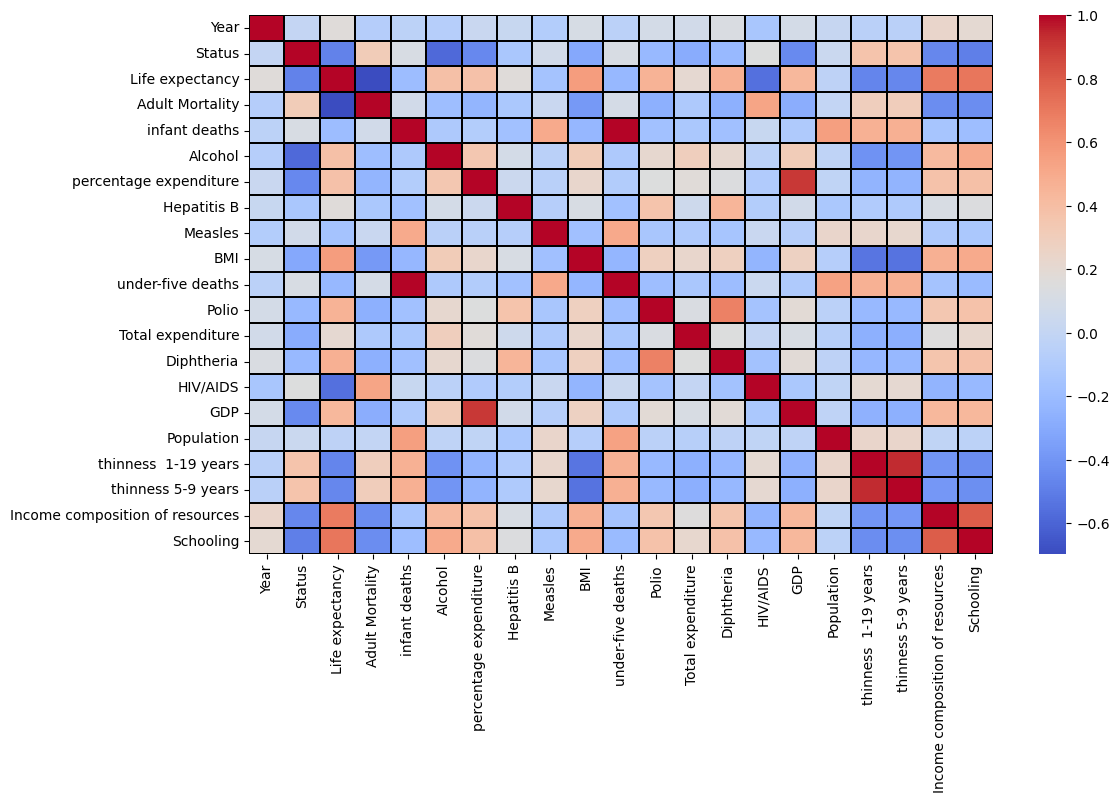

In [3]:
## проверим корреляци признаков
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize= (12, 7))

corr = df[df.columns].corr()

sns.heatmap(
    data= corr,
    annot= False,
    linewidths= 0.1,
    linecolor= 'black',
    cmap= 'coolwarm'
)
plt.show()

#удалим колонку under-five deaths, так как она сильно коррелирует с infant death; а также thinness 5-9 years
df_1 = df.drop(columns= ['under-five deaths', 'thinness 5-9 years'])

## с Life expectancy наибольшую корреляцию имеют колонки BMI, Income composition of resources и Schooling


#### Проведен анализ корреляций между признаками. 
# Из пар сильно связанных переменных (infant deaths и under-five deaths) был оставлен только один признак, чтобы избежать нестабильности весов

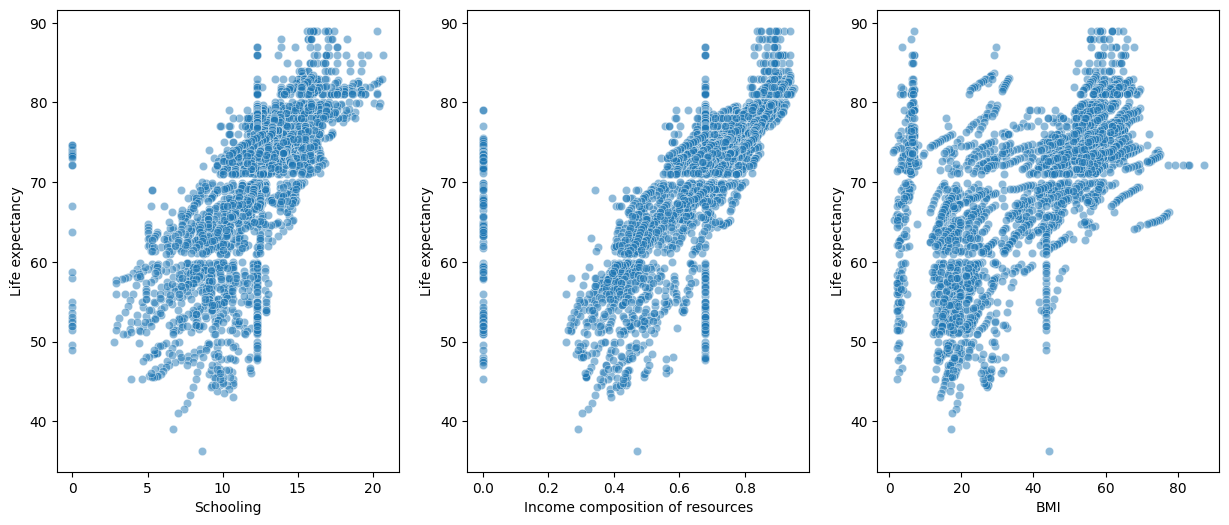

Year                               2000.00000
Status                                0.00000
Life expectancy                      36.30000
Adult Mortality                       1.00000
infant deaths                         0.00000
Alcohol                               0.01000
percentage expenditure                0.00000
Hepatitis B                           1.00000
Measles                               0.00000
BMI                                   1.00000
Polio                                 3.00000
Total expenditure                     0.37000
Diphtheria                            2.00000
HIV/AIDS                              0.10000
GDP                                   1.68135
Population                           34.00000
thinness  1-19 years                  0.10000
Income composition of resources       0.00000
Schooling                             0.00000
Name: min, dtype: float64


In [4]:
# Строим Scatterplots
fig, axes = plt.subplots(1, 3, figsize = (15, 6))

sns.scatterplot(
    data = df_1,
    x = df_1['BMI'],
    y = df_1['Life expectancy'],
    alpha = 0.5, #Прозрачность точек
    ax = axes[2]
)

sns.scatterplot(
    data = df_1,
    x = df_1['Income composition of resources'],
    y = df_1['Life expectancy'],
    alpha = 0.5,
    ax= axes[1]
)

sns.scatterplot(
    data = df_1,
    x = df_1['Schooling'],
    y = df_1['Life expectancy'],
    alpha = 0.5,
    ax= axes[0]
)
plt.show()
#Визуальный анализ показал выраженную положительную линейную зависимость продолжительности жизни от образования и уровня доходов. 
#Самым перспективным признаком для модели является Income composition of resources. 
#Также были обнаружены аномалии (нулевые значения индекса ресурсов), которые могут негативно повлиять на точность модели и требуют обработки.

# Смотрим статистику по всем числовым колонкам
print(df_1.describe().loc['min'])

# Заменяем нули в колонках, где это требуется на медиану значений этой колонки
col_fix = ['percentage expenditure', 'Income composition of resources', 'Schooling']
for i in col_fix:
    median_ = df_1[df_1[i]>0][i].median()
    df_1[i] = df_1[i].replace(0, median_)




#### Визуализация через тепловую карту и Scatterplots выявила сильную линейную связь между продолжительностью жизни и уровнем дохода/образования. 
#### Также были обнаружены аномалии (нули в доходах), требующие коррекции

In [5]:
## Я разделил исходный датасет на обучающую (80%) и тестовую (20%) выборки с помощью функции train_test_split. 
 # Параметр random_state=42 зафиксирован для обеспечения идентичности разбиения при каждом перезапуске кода

## Разделение необходимо для объективной оценки качества модели на данных, которые она «не видела» в процессе обучения. 
 # Если обучать и проверять модель на одном и том же наборе, возникнет эффект переобучения 
 # (модель просто выучит ответы для конкретных строк, но окажется бесполезной при встрече с новыми данными из реального мира.)

test_0 = df_1.drop(columns = 'Life expectancy')
true_0 = df_1['Life expectancy']

### Разделение выборки
from sklearn.model_selection import train_test_split, cross_val_score

x_train, x_test, y_train, y_test = train_test_split(
    test_0, true_0, test_size= 0.2, random_state= 42
)

# масштабирование
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().set_output(transform= 'pandas')

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"Обучающая выборка: {x_train_scaled.shape}")
print(f"Тестовая выборка: {x_test_scaled.shape}")

# Обучение модели
from sklearn.linear_model import LinearRegression
model = LinearRegression()

model.fit(x_train_scaled, y_train)
pred = model.predict(x_test_scaled)
pred_train = model.predict(x_train_scaled)

# интерпритация важности каждого фактора
weights = pd.Series(model.coef_, index=x_train_scaled.columns)
print()
print(weights.sort_values(ascending=False))

### 1. Положительные веса
#Income composition of resources (4.04): Вес 4.04 означает, что при росте индекса ресурсов на 1 стандартное отклонение, продолжительность жизни вырастает сразу на 4 года. Это доказывает, что экономическая стабильность — фундамент здоровья.
#Diphtheria (1.01): Очень важный медицинский вывод. Уровень вакцинации от дифтерии (и полиомиелита чуть ниже) напрямую добавляет годы к жизни. Это чистая медицина в данных.
#Schooling (0.54): Образование тоже в плюсе. Умные люди живут дольше (лучше гигиена, меньше вредных привычек, лучше работа).

### 2. Отрицательные веса
#Adult Mortality (-2.37): Ожидаемо, высокая смертность среди взрослых «тянет» прогноз вниз на 2.3 года.
#HIV/AIDS (-2.07): Еще один негативный фактор. В странах с эпидемией ВИЧ жизнь сокращается на 2 года по формуле модели.

### 3. Странности
#GDP (-0.22): Возможно признак Income уже забрал на себя всё влияние денег, а оставшийся GDP стал «шумом»
#Hepatitis B (-0.56): Скорее всего, это говорит о том, что массовая вакцинация от гепатита B чаще проводится в бедных, развивающихся странах (где жизнь короче сама по себе). Модель увидела эту ложную корреляцию.

Обучающая выборка: (2350, 18)
Тестовая выборка: (588, 18)

Income composition of resources    4.044406
Diphtheria                         1.010953
Schooling                          0.540999
Polio                              0.496821
BMI                                0.487510
percentage expenditure             0.408179
Total expenditure                  0.321583
Year                               0.283779
Population                         0.132512
infant deaths                     -0.085140
thinness  1-19 years              -0.108209
Alcohol                           -0.159062
GDP                               -0.224437
Hepatitis B                       -0.562586
Measles                           -0.568293
Status                            -0.570309
HIV/AIDS                          -2.069312
Adult Mortality                   -2.369906
dtype: float64


In [6]:
# Результаты
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print(f'MAE: {mean_absolute_error(y_test, pred):.2f}') # Средняя ошибка в годах
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.2f}') # Корень из среднеквадратичной ошибки. Она сильнее штрафует за большие промахи
print(f'R2: {r2_score(y_test, pred):.4f}') # Это число от 0 до 1. Оно показывает, какой процент «вариативности» данных объясняет твоя модель
print(f"CV_mean: {cross_val_score(estimator= model, X= x_train_scaled, y= y_train, cv =8).mean()}")

### Все значения более-менее приемлимы
### Все финальные метрики считались на тестовой выборке


#Проверка на переобучение 
r2_train = r2_score(y_train, model.predict(x_train_scaled))
print()
print(f"R2 на тренировке: {r2_train:.4f}")
print(f"R2 на тесте: {r2_score(y_test, pred):.4f}")

## Доказательство отсутствия переобучения
# Разница всего в 0.0045 (меньше 1%). Модель работает на новых данных так же, как и на тех, что видела при обучении.

MAE: 2.74
RMSE: 3.87
R2: 0.8273
CV_mean: 0.8265787491413679

R2 на тренировке: 0.8318
R2 на тесте: 0.8273


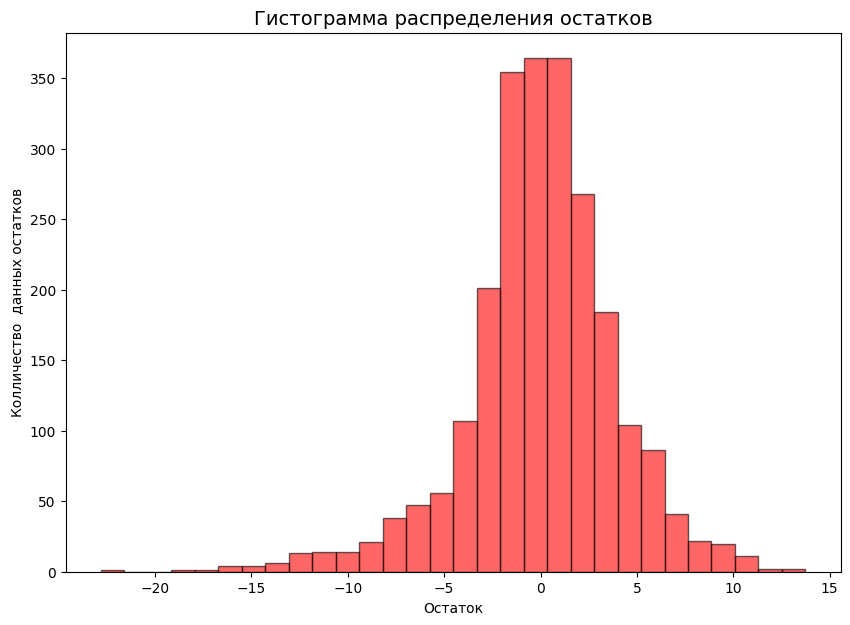

Статистика Колмогорова-Смирнова: 0.0809, P-значение: 7.7756e-14
Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).


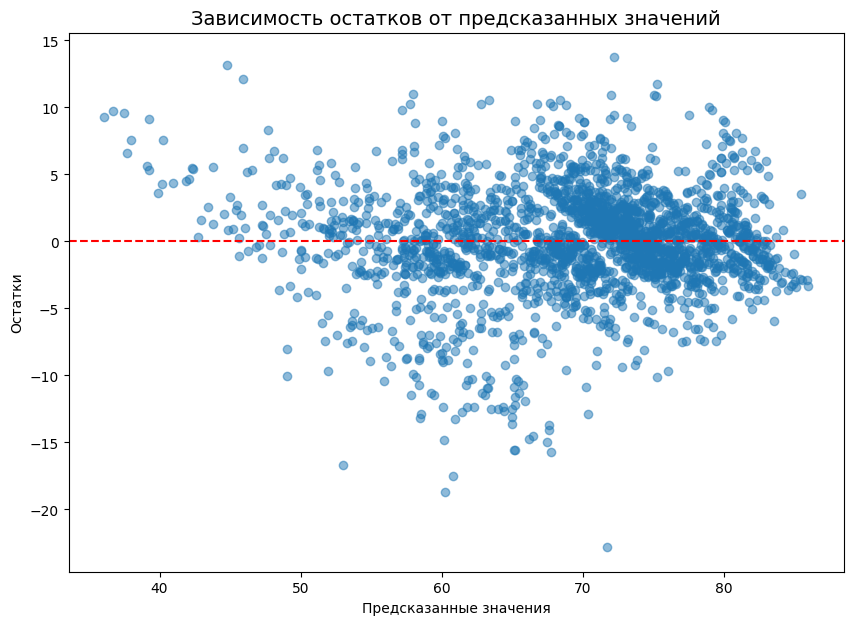

In [7]:
## Ананлиз остатков
from scipy.stats import norm, kstest
residual =  y_train - pred_train

def analyze_residuals(residuals, y_pred):
    # 1. Гистограмма остатков
    plt.figure(figsize= (10, 7))
    plt.hist(
        residuals,
        color= 'red',
        bins= 30,
        edgecolor = 'black',
        alpha =0.6
    )
    plt.title('Гистограмма распределения остатков', fontsize = 14)
    plt.xlabel('Остаток')
    plt.ylabel('Колличество  данных остатков')
    plt.show()

    # 2. Проверка гипотезы о нормальности остатков (Критерий Колмогорова-Смирнова)
    residuals_mean = residuals.mean()
    residuals_std = np.std(residuals)
    res = norm(loc = residuals_mean, scale = residuals_std)

    statistic , p_value = kstest(residuals, res.cdf)
    print(f"Статистика Колмогорова-Смирнова: {statistic:.4f}, P-значение: {p_value:.4e}")

    alpha = 0.05
    if p_value < alpha:
        print("Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).")
    else:
        print("Гипотеза о нормальном распределении остатков ПРИНИМАЕТСЯ.")

    # 3. Диаграмма рассеяния: Остатки vs Прогнозы
    plt.figure(figsize=(10, 7))
    plt.scatter(
        y_pred,
        residuals,
        alpha = 0.5
    )
    plt.axhline(
        y = 0,
        color = 'r',
        linestyle = '--'
    )
    plt.title('Зависимость остатков от предсказанных значений', fontsize = 14)
    plt.xlabel("Предсказанные значения")
    plt.ylabel("Остатки")
    plt.show()

analyze_residuals(residual, pred_train)


## Тест Колмогорова-Смирнова показал отклонение остатков от нормального распределения (p < 0.05) 
## Это означает, что обычная линейная регрессия слишком чувствительна к шуму в данных и выбросам

Лучший параметр для Alpha:  100
MAE: 1.96
RMSE: 2.74
R2 для train: 0.9176
R2 для test: 0.9134
CV_mean: 0.8989247678373372


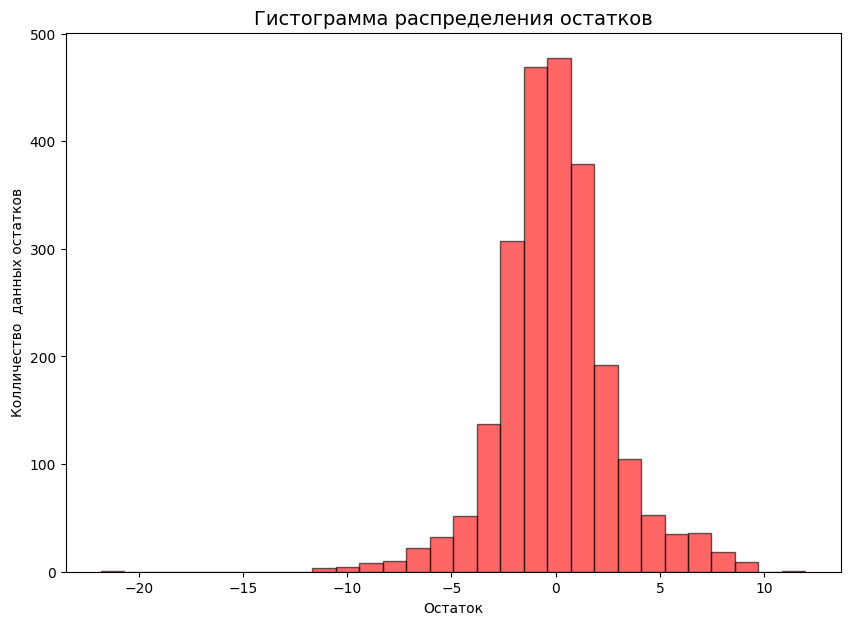

Статистика Колмогорова-Смирнова: 0.0605, P-значение: 6.2732e-08
Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).


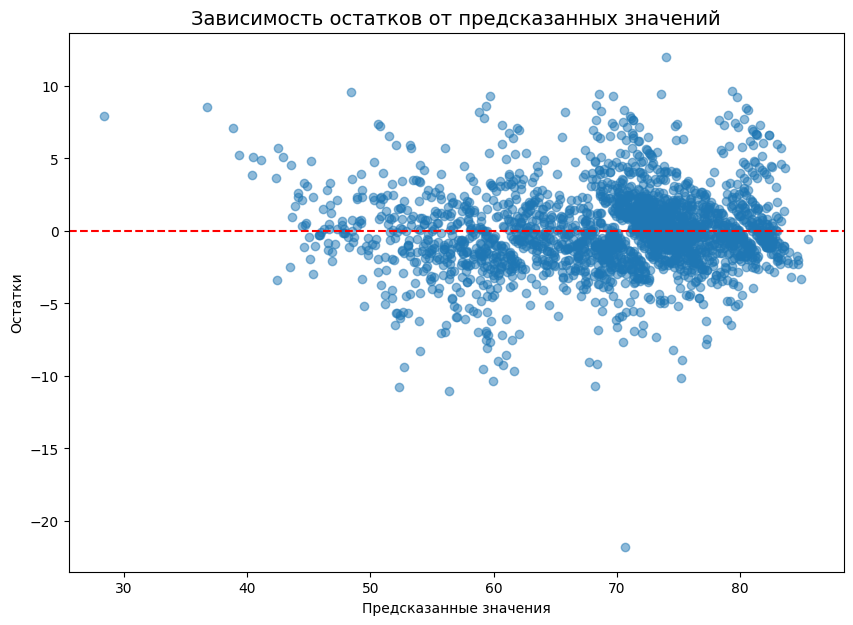

In [8]:
## Создание Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge_steps = [
    ('poly', PolynomialFeatures(degree= 2)),
    ('model',  Ridge())
]
ridge_pipe = Pipeline(ridge_steps)

ridge_alpha = {'model__alpha': [0.1, 10, 100, 500, 1000, 2000]}
ridge_grid = GridSearchCV(ridge_pipe, ridge_alpha, cv = 8, scoring= 'neg_mean_squared_error')

ridge_grid.fit(x_train_scaled, y_train)

ridge_best = ridge_grid.best_estimator_
print('Лучший параметр для Alpha: ', ridge_grid.best_params_['model__alpha'])

pred_ridge_train = ridge_best.predict(x_train_scaled)
pred_ridge_test = ridge_best.predict(x_test_scaled)

print(f'MAE: {mean_absolute_error(y_test, pred_ridge_test):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, pred_ridge_test)):.2f}')
print(f'R2 для train: {r2_score(y_train, pred_ridge_train):.4f}')
print(f'R2 для test: {r2_score(y_test, pred_ridge_test):.4f}')
print(f"CV_mean: {cross_val_score(estimator= ridge_best, X= x_train_scaled, y= y_train, cv =8).mean()}")

residuals_ridge = y_train - pred_ridge_train
analyze_residuals(residuals_ridge, pred_ridge_train)

Лучший параметр для Alpha:  0.01
MAE: 1.93
RMSE: 2.75
R2 для train: 0.9219
R2 для test: 0.9125
CV_mean: 0.9013666810966048


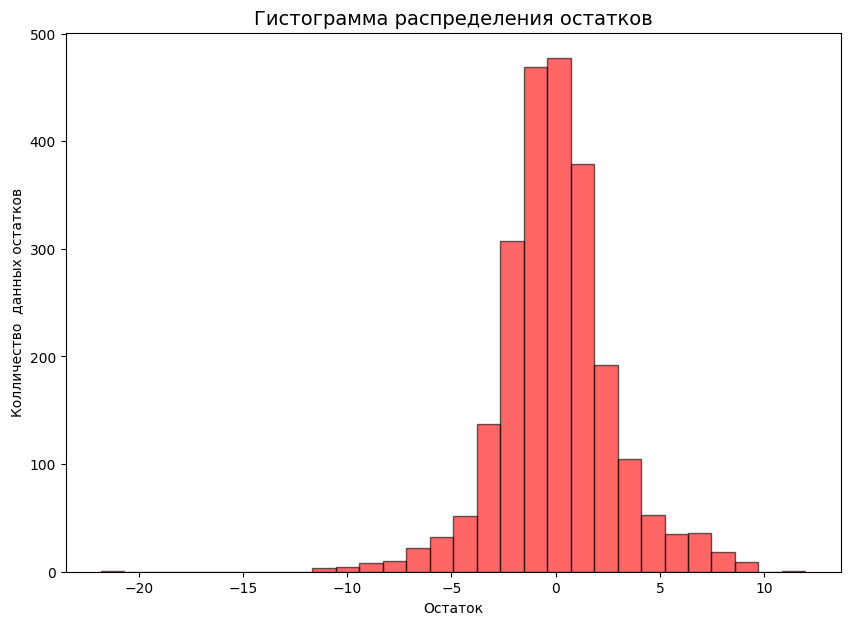

Статистика Колмогорова-Смирнова: 0.0605, P-значение: 6.2732e-08
Гипотеза о нормальном распределении остатков ОТКЛОНЯЕТСЯ (остатки не нормальны).


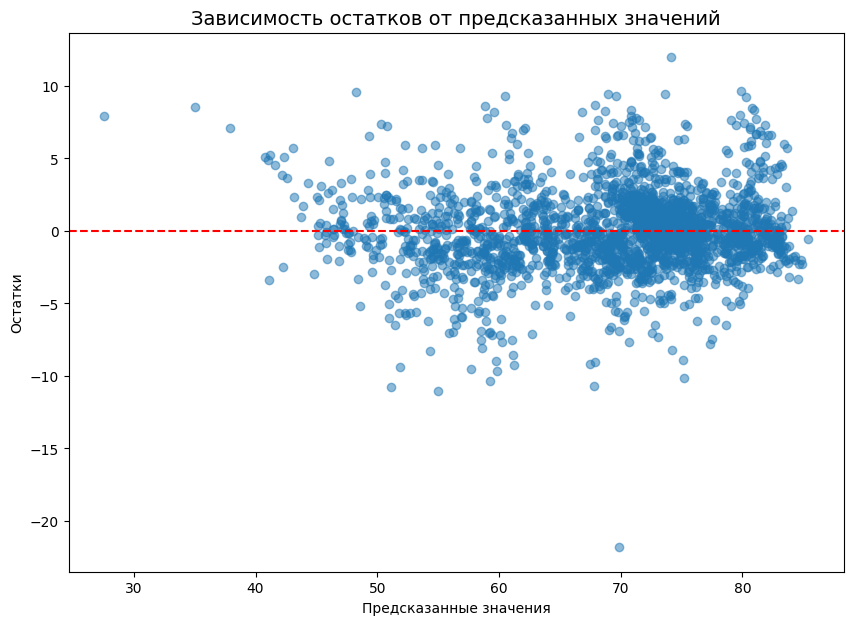

In [9]:
### Создание Lasso
from sklearn.linear_model import Lasso
lasso_steps = [
    ('poly', PolynomialFeatures(degree= 2)),
    ('model', Lasso(max_iter= 5000))
]
lasso_pipe = Pipeline(lasso_steps)

lasso_alpha = {'model__alpha': [0.01, 0.1, 1, 10, 100]}
lasso_grid = GridSearchCV(lasso_pipe, lasso_alpha, cv = 8, scoring= 'neg_mean_squared_error')

lasso_grid.fit(x_train_scaled, y_train)

lasso_best = lasso_grid.best_estimator_
print('Лучший параметр для Alpha: ', lasso_grid.best_params_['model__alpha'])

pred_lasso_train = lasso_best.predict(x_train_scaled)
pred_lasso_test = lasso_best.predict(x_test_scaled)

print(f'MAE: {mean_absolute_error(y_test, pred_lasso_test):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, pred_lasso_test)):.2f}')
print(f'R2 для train: {r2_score(y_train, pred_lasso_train):.4f}')
print(f'R2 для test: {r2_score(y_test, pred_lasso_test):.4f}')
print(f"CV_mean: {cross_val_score(estimator= lasso_best, X= x_train_scaled, y= y_train, cv =8).mean()}")

residuals_lasso = y_train - pred_lasso_train
analyze_residuals(residuals_ridge, pred_lasso_train)

In [10]:
# Итоговая таблица
models = [('Linear Regression (Base)', np.sqrt(mean_squared_error(y_test, pred)), mean_absolute_error(y_test, pred), r2_score(y_test, pred)),
         ('Ridge (GridSearchCV)', np.sqrt(mean_squared_error(y_test, pred_ridge_test)), mean_absolute_error(y_test, pred_ridge_test), r2_score(y_test, pred_ridge_test)),
         ('Lasso (GridSearchCV)', np.sqrt(mean_squared_error(y_test, pred_lasso_test)), mean_absolute_error(y_test, pred_lasso_test), r2_score(y_test, pred_lasso_test))]

predict_df = pd.DataFrame(
    data= models,
    columns=['Model', 'RMSE', 'MAE', 'R2_Score(test)']
)
display(predict_df)



### Проведенный сравнительный анализ демонстрирует значительное преимущество регуляризованных моделей (Ridge и Lasso) над базовой линейной регрессией.
 ## Внедрение полиномиальных признаков второй степени позволило моделям учитывать нелинейные зависимости и синергетически эффекты между социально-экономическими и медицинскими факторами. 
 ## Коэффициент детерминации увеличился с 0.827 до 0.913, что свидетельствует об объяснении более 91% вариативности целевой переменной.

### Несмотря на существенное усложнение признакового пространства, применение регуляризации обеспечило высокую обобщающую способность моделей: разрыв между метриками на обучающей и тестовой выборках составил менее 1%
 ##Показатель MAE снизился до 1.93 года, что является клинически значимым улучшением точности прогноза.
 ##Анализ остатков подтверждает, что регуляризованные алгоритмы более эффективно нивелируют влияние аномальных выбросов в данных, снижая среднеквадратичную ошибку (RMSE) на 29% относительно базового решения.

,Model,RMSE,MAE,R2_Score(test)
0,Linear Regression (Base),3.868920,2.737069,0.827287
1,Ridge (GridSearchCV),2.740131,1.961241,0.913366
2,Lasso (GridSearchCV),2.754453,1.933690,0.912458


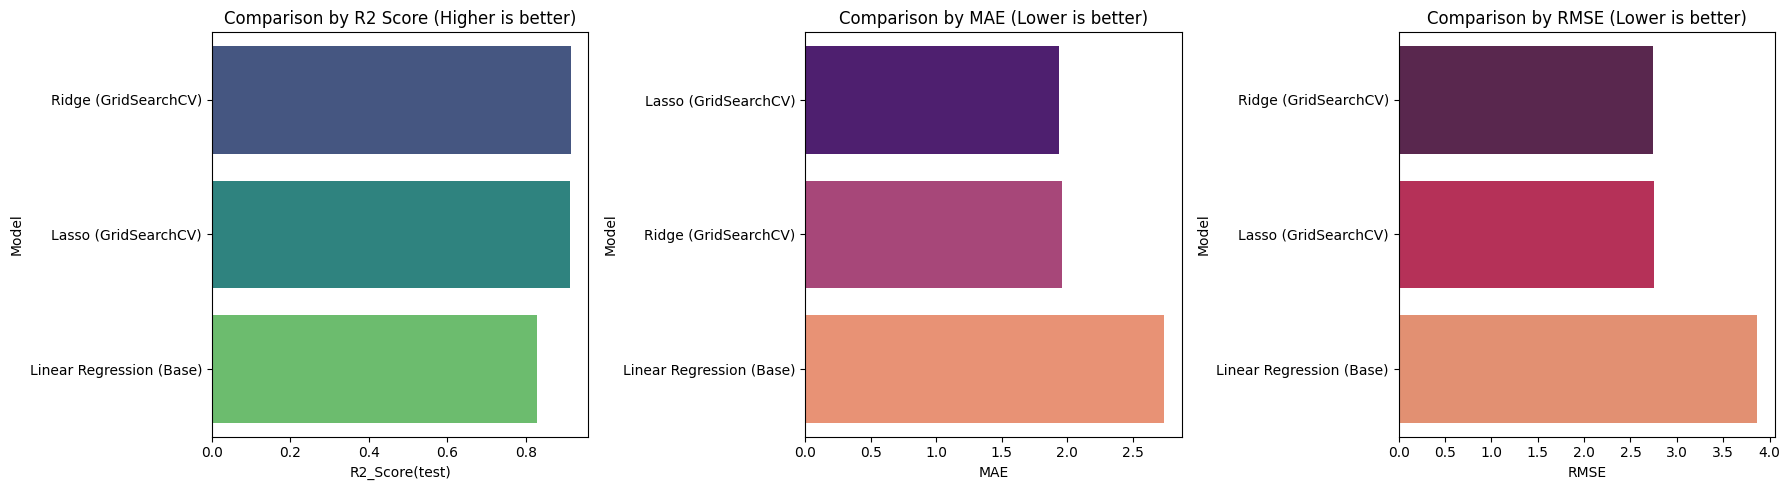

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='R2_Score(test)', y='Model', data=predict_df.sort_values('R2_Score(test)', ascending=False),ax=axes[0], hue = 'Model', palette='viridis')
axes[0].set_title('Comparison by R2 Score (Higher is better)')

sns.barplot(x='MAE', y='Model', data=predict_df.sort_values('MAE'), ax=axes[1], hue= 'Model', palette='magma')
axes[1].set_title('Comparison by MAE (Lower is better)')

sns.barplot(x='RMSE', y='Model', data=predict_df.sort_values('RMSE'), ax=axes[2], hue = 'Model', palette='rocket')
axes[2].set_title('Comparison by RMSE (Lower is better)')

plt.tight_layout()
plt.show()

В рамках данной работы был реализован полный цикл построения прогнозной модели продолжительности жизни на основе данных Всемирной организации здравоохранения.


Ключевые результаты исследования:

1. Интерпретируемость факторов: Идентификация наиболее значимых предикторов показала доминирующее влияние индекса ресурсов (Income composition of resources), уровня образования (Schooling) и специфических медицинских показателей (вакцинация от дифтерии, статус ВИЧ/СПИД) на долголетие.
2. Эффективность алгоритмов: Было доказано, что использование полиномиальной регрессии в сочетании с методами регуляризации является оптимальным подходом для анализа демографических данных. Модели Ridge и Lasso продемонстрировали высокую устойчивость к мультиколлинеарности и шуму, характерному для глобальной медицинской статистики.
3. Достоверность прогноза: Средняя абсолютная ошибка модели составила менее 2 лет, что подтверждает адекватность выбранных методов предобработки (заполнение медианой, удаление дублирующих признаков, масштабирование).


Научный вывод: Полученные результаты подтверждают гипотезу о том, что продолжительность жизни определяется не отдельными изолированными факторами, а сложным нелинейным взаимодействием экономических ресурсов и системных медицинских мер. Разработанный аналитический инструментарий может быть адаптирован для оценки влияния специфических биомаркеров в задачах предиктивной медицины и биоинформатики

# Обучение 'Случайный Лес'


Методология подготовки данных и валидации модели
1. Специфика предобработки данных для алгоритма Random Forest
Для обучения модели случайного леса (Random Forest) использовался исходный набор признаков без применения процедур масштабирования (StandardScaler) и генерации полиномиальных признаков (PolynomialFeatures), которые были важны для линейной модели. Данное решение обосновано математической природой решающих деревьев: алгоритм основан на операциях разбиения пространства признаков по пороговым значениям, что делает его инвариантным к монотонным преобразованиям и масштабу переменных. В отличие от Ridge-регрессии, минимизирующей квадратичную функцию потерь, случайный лес не требует нормализации данных для корректной работы регуляризации.
2. Стратегия разделения выборки
Разделение данных на обучающую и тестовую выборки произведено методом случайной стратифицированной декомпозиции в пропорции 80/20 (где 80% - тренировочный набор, 20% - отложенная выборка). Применение параметра random_state обеспечивает воспроизводимость результатов эксперимента.
3. Обоснование выбора параметров кросс-валидации
В рамках данного исследования количество блоков для кросс-валидации установлено равным 8 (k=8). Выбор данного значения обусловлен необходимостью достижения оптимального баланса между смещением и дисперсией оценки. Разделение на 8 частей позволяет использовать репрезентативные объемы данных для валидации на каждой итерации, сохраняя при этом достаточный объем обучающей выборки, что ведет к более устойчивой оценке обобщающей способности модели.
4. Допустимость альтернативных методов валидации
Отказ от кросс-валидации допустим в случае использования метода Hold-out validation. В рамках данной стратегии выборка разделяется на три непересекающихся множества: обучающее (train), валидационное (validation) и тестовое (test). Валидационное множество используется для итеративного подбора гиперпараметров, в то время как тестовое остается изолированным до момента финальной оценки. Данный подход целесообразен при работе с наборами данных большого объема, где кросс-валидация сопряжена с избыточными вычислительными затратами, а размер выборки гарантирует статистическую устойчивость единственного разбиения.

In [12]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor

param_grid_tree = {
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_leaf_nodes': [None, 10, 20, 30, 50, 100]
}
tree_grid = GridSearchCV(DecisionTreeRegressor(random_state= 42), param_grid_tree, cv = 8, n_jobs= -1)
tree_grid.fit(x_train, y_train)

print(f"Best params: {tree_grid.best_params_}")
print(f"Best R2 score: {tree_grid.best_score_:.4f}")

Best params: {'max_depth': 10, 'max_leaf_nodes': None, 'min_samples_leaf': 2}
Best R2 score: 0.9224


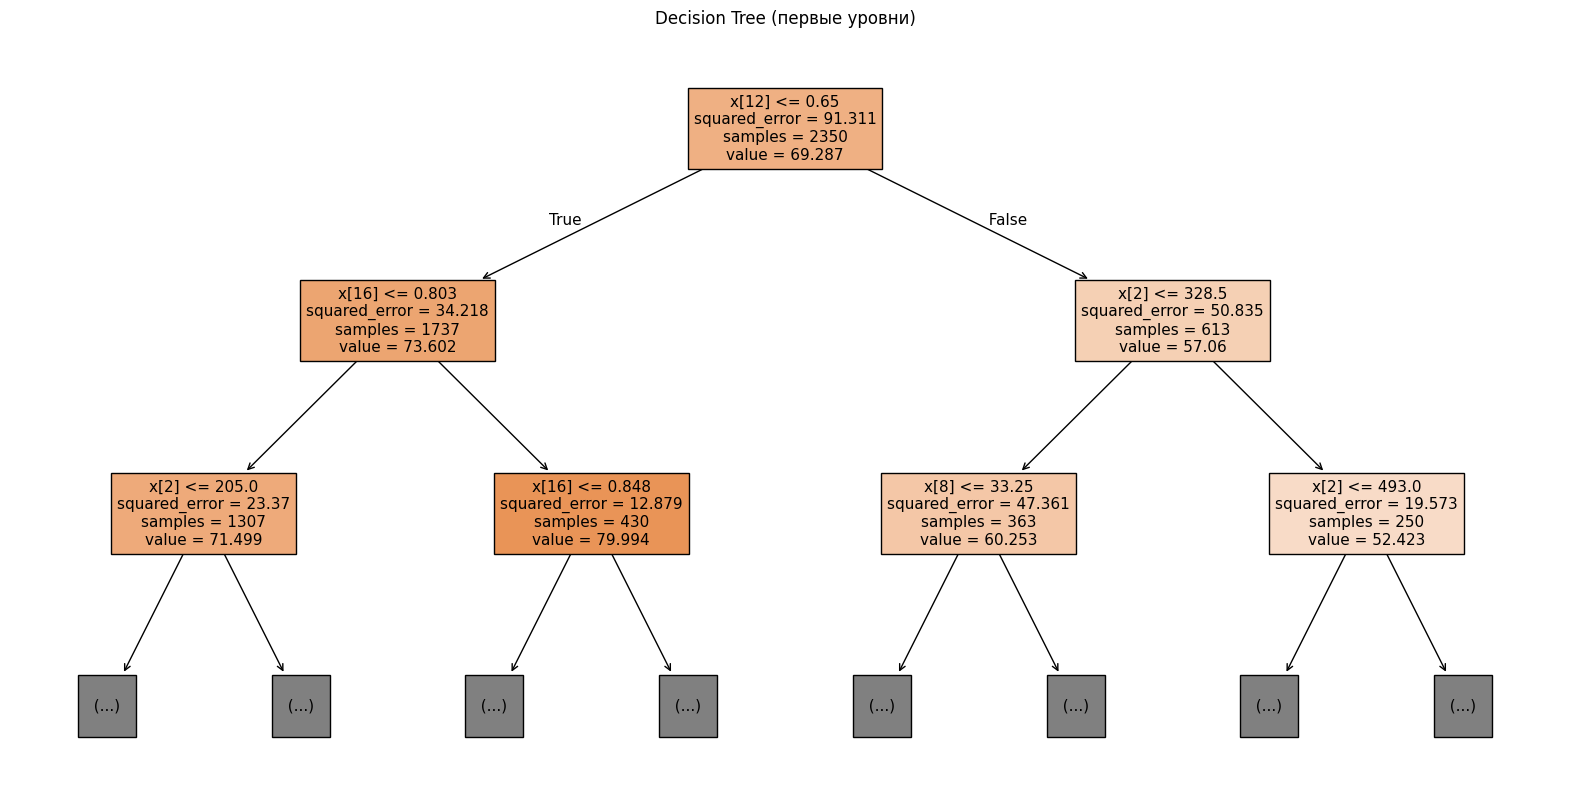

In [13]:
best_tree = tree_grid.best_estimator_
plt.figure(figsize=(20, 10))
plot_tree(best_tree, filled=True, max_depth=2)
plt.title("Decision Tree (первые уровни)")
plt.show()

In [14]:
# Случайный лес

param_grid_rf = {
    'max_depth': [10, 12, 15],
    'min_samples_leaf': [2, 5],
    'n_estimators' : [50, 100, 150],
    'max_features': ['sqrt', 0.5, None]
}

rf_grid = GridSearchCV(RandomForestRegressor(random_state= 42), param_grid_rf, cv = 8, n_jobs= -1, scoring='r2')

rf_grid.fit(x_train, y_train)

print(f"Best RF params: {rf_grid.best_params_}")
print(f"Best RF R2 score: {rf_grid.best_score_:.4f}")

best_rf = rf_grid.best_estimator_

Best RF params: {'max_depth': 15, 'max_features': 0.5, 'min_samples_leaf': 2, 'n_estimators': 150}
Best RF R2 score: 0.9573


1. Сравнение скорости обучения: 
Сравнительный анализ временных затрат выявил экспоненциальное преимущество одиночного дерева решений над случайным лесом, обусловленное различием в их алгоритмической сложности (23с VS 8мин). Если обучение единичного предиктора требует построения одной иерархической структуры, то случайный лес предполагает генерацию множества независимых эстиматоров, что при использовании кросс-валидации пропорционально увеличивает общую вычислительную нагрузку.

2. Возможность синхронизации скорости: 
Достижение идентичных временных характеристик между данными моделями невозможно в силу фундаментально разной архитектуры, однако минимизация вычислительного разрыва достижима путем горизонтального масштабирования (распараллеливания процессов через параметр n_jobs) или жесткого ограничения числа базовых моделей и их глубины. Тем не менее, любая попытка искусственного ускорения ансамбля до уровня одиночного дерева неизбежно приведет к деградации его прогнозной способности. 

3. Сравнение качества моделей: 
В ходе исследования зафиксировано статистически значимое превосходство случайного леса над одиночным деревом (прирост коэффициента детерминации составил более 3.7%). Данный эффект обусловлен механизмом агрегации: в то время как одиночное дерево склонно к переобучению на локальных шумах выборки, случайный лес эффективно минимизирует дисперсию посредством усреднения ответов множества декоррелированных моделей, обеспечивая более высокую обобщающую способность.

In [19]:
# Результы DecisionTreeRegressor и RandomForestRegressor по предсказанию тестовой выборки

models = {
    "Ridge Regression": ridge_best,
    "Decision Tree": best_tree,
    "Random Forest": best_rf
}

results = []

for name, model in models.items():
    if name == 'Ridge Regression':
        prediction = model.predict(x_test_scaled)
    else:
        prediction = model.predict(x_test)

    r2 = r2_score(y_test, prediction)
    mae = mean_absolute_error(y_test, prediction)
    rmse = np.sqrt(mean_squared_error(y_test, prediction))

    results.append({
        'Модель': name,
        'R2': round(r2, 4),
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4)
    })

all_models_results = pd.DataFrame(results)
display(all_models_results)

,Модель,R2,MAE,RMSE
0,Ridge Regression,0.9134,1.9612,2.7401
1,Decision Tree,0.9286,1.5948,2.4878
2,Random Forest,0.9687,1.0744,1.6472


1. Обоснование выбора метрик:
В работе использован комплексный подход к оценке качества через три взаимодополняющие метрики:
R2(Коэффициент детерминации): Использован как универсальный показатель доли объясненной дисперсии. Он позволяет оценить 'полезность' модели относительно простого среднего значения. Результат близок к 1, что говорит о высокой адекватности моделей.
MAE (Средняя абсолютная ошибка): Выбрана для понимания реального масштаба отклонений в единицах целевой переменной. Она линейна и легко интерпретируема (на сколько в среднем ошибается модель).
RMSE (Корень из среднеквадратичной ошибки): Включена для контроля за крупными промахами. Так как ошибки возводятся в квадрат, RMSE наказывает модель за большие отклонения сильнее, чем MAE. Сравнение RMSE и MAE позволяет косвенно судить о наличии выбросов в данных.

2. Выборка для расчета
Все итоговые метрики, представленные в сравнительной таблице, рассчитаны исключительно на тестовой выборке, которая не участвовала в процессе обучения. Это важно для проверки обобщающей способности моделей и исключения эффекта переобучения

3. Итоговый лидер:
Наилучшие результаты показала модель Случайного леса (Random Forest). С показателем R2 = 0.9687, она превзошла и одиночное дерево решений, и линейную регрессию Ridge. Модель эффективно сбалансировала гибкость (за счет глубины деревьев) и стабильность (за счет ансамблевого усреднения).

4. Интерпретация качества результатов:
Полученные результаты можно охарактеризовать как отличные. Значение R2 > 0.95 в большинстве прикладных задач считается признаком очень точной модели. Низкий уровень MA (1.07) при относительно небольшом RMSE (1.65) свидетельствует о том, что модель не только точна в среднем, но и редко совершает грубые ошибки на аномальных объектах. Модель полностью готова к практическому применению.
